In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import f_regression
from sklearn.preprocessing import LabelEncoder 

sns.set(style='whitegrid')

df = pd.read_csv('cleaned_cafe_sales.csv')

In [19]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Transaction Date
0,TXN_6234882,Cookie,4.000000,1.000000,4.000000,Credit Card,2023-01-01
1,TXN_4801947,Juice,1.000000,3.000000,3.000000,Digital Wallet,2023-01-01
2,TXN_8842223,Sandwich,5.000000,2.951766,14.758828,Digital Wallet,2023-01-01
3,TXN_5728991,Salad,3.029846,5.000000,15.149228,Unkwown,2023-01-01
4,TXN_2192787,Sandwich,5.000000,4.000000,20.000000,Cash,2023-01-01


In [20]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

df['Month']     = df['Transaction Date'].dt.month
df['DayOfWeek'] = df['Transaction Date'].dt.dayofweek
df['DayOfMont'] = df['Transaction Date'].dt.day_of_year
df['Hour'] = df['Transaction Date'].dt.hour

In [21]:
le = LabelEncoder()

df['Item_encoded'] = le.fit_transform(df['Item'])
df['Payment Method_encoded'] = le.fit_transform(df['Payment Method'])

print('Kolom setelah feature engineering')
print(df.columns.tolist())
df.head()

Kolom setelah feature engineering
['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Transaction Date', 'Month', 'DayOfWeek', 'DayOfMont', 'Hour', 'Item_encoded', 'Payment Method_encoded']


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Transaction Date,Month,DayOfWeek,DayOfMont,Hour,Item_encoded,Payment Method_encoded
0,TXN_6234882,Cookie,4.000000,1.000000,4.000000,Credit Card,2023-01-01,1,6,1,0,2,1
1,TXN_4801947,Juice,1.000000,3.000000,3.000000,Digital Wallet,2023-01-01,1,6,1,0,3,2
2,TXN_8842223,Sandwich,5.000000,2.951766,14.758828,Digital Wallet,2023-01-01,1,6,1,0,5,2
3,TXN_5728991,Salad,3.029846,5.000000,15.149228,Unkwown,2023-01-01,1,6,1,0,4,3
4,TXN_2192787,Sandwich,5.000000,4.000000,20.000000,Cash,2023-01-01,1,6,1,0,5,0


In [22]:
# Pilih kolom numerik yang akan dianalisis.
numeric_features = ['Quantity', 'Price Per Unit', 'Total Spent', 'Month', 'DayOfWeek', 'DayOfMont', 'Item_encoded', 'Payment Method_encoded']

df_numeric = df[numeric_features]

# Hitung Correlation Matrix
corr_matrix = df_numeric.corr(method='pearson')

print('Pearson Correlation Matrix:')
corr_matrix.round(3)

Pearson Correlation Matrix:


,Quantity,Price Per Unit,Total Spent,Month,DayOfWeek,DayOfMont,Item_encoded,Payment Method_encoded
Quantity,1.000,0.002,0.706,-0.004,0.001,-0.004,0.006,-0.006
Price Per Unit,0.002,1.000,0.644,-0.013,-0.001,-0.011,0.228,-0.023
Total Spent,0.706,0.644,1.000,-0.006,0.004,-0.005,0.152,-0.019
Month,-0.004,-0.013,-0.006,1.000,0.018,0.997,-0.007,-0.011
DayOfWeek,0.001,-0.001,0.004,0.018,1.000,0.018,-0.009,0.001
DayOfMont,-0.004,-0.011,-0.005,0.997,0.018,1.000,-0.006,-0.011
Item_encoded,0.006,0.228,0.152,-0.007,-0.009,-0.006,1.000,0.002
Payment Method_encoded,-0.006,-0.023,-0.019,-0.011,0.001,-0.011,0.002,1.000


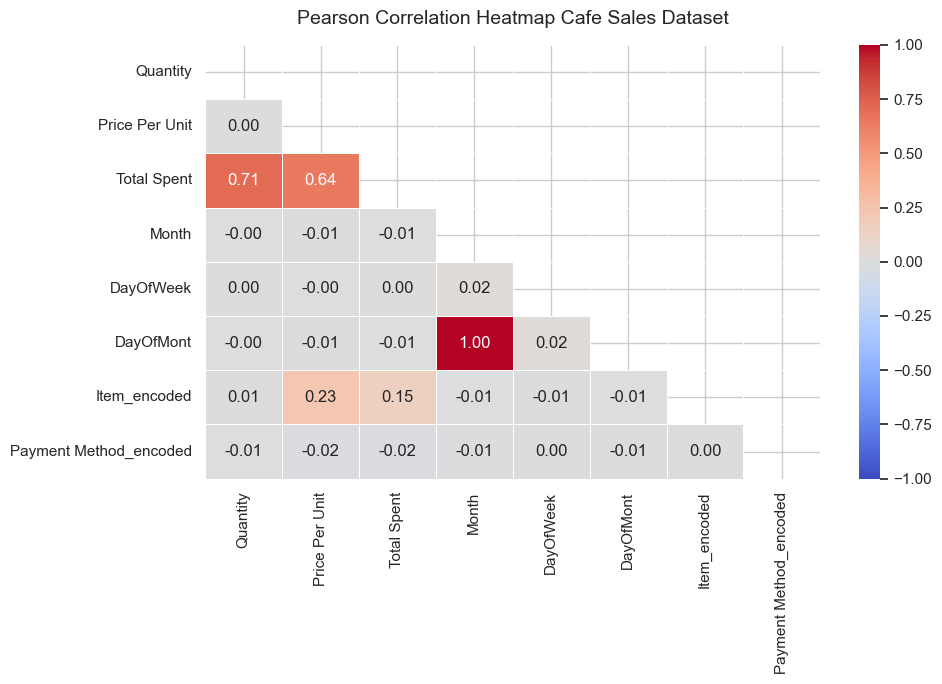

In [23]:
#Visualisasi: Heatmap Korelasi
plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # sembunyikan segitiga atas

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    mask=mask,
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title('Pearson Correlation Heatmap Cafe Sales Dataset', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [24]:
# Korelasi Setiap Fitur Terhadap Target (Total Spent)
target = 'Total Spent'
corr_with_target = (
    df_numeric.corr(method='pearson')[target]
    .drop(target)  # hapus korelasi target dengan dirinya sendiri
    .sort_values(key=abs, ascending=False)
)

print("Korelasi fitur dengan target (Total Spent))")
print(corr_with_target.to_string())

Korelasi fitur dengan target (Total Spent))
Quantity                  0.705991
Price Per Unit            0.644480
Item_encoded              0.151638
Payment Method_encoded   -0.019353
Month                    -0.005859
DayOfMont                -0.005376
DayOfWeek                 0.004408


In [25]:
#Seleksi Fitur Berdasarkan Threshold Korelasi

THRESHOLD = 0.1 #Fitur dengan korelasi > threshold dianggap relevan

selected_by_pearson = corr_with_target[abs(corr_with_target) > THRESHOLD].index.tolist()
dropped_by_pearson = corr_with_target[abs(corr_with_target) < THRESHOLD].index.tolist()

print(f'Threshold korelasi: r >= {THRESHOLD}')
print(f'\nFitur DIPILIH ({len(selected_by_pearson)}): {selected_by_pearson}')
print(f'Fitur DIBUANG ({len(dropped_by_pearson)}): {dropped_by_pearson}')

Threshold korelasi: r >= 0.1

Fitur DIPILIH (3): ['Quantity', 'Price Per Unit', 'Item_encoded']
Fitur DIBUANG (4): ['Payment Method_encoded', 'Month', 'DayOfMont', 'DayOfWeek']


In [26]:
x = df_numeric.drop(['Total Spent'], axis=1)
y = df_numeric['Total Spent']

print('Shape X:', x.shape)
print('Shape y:', y.shape)

Shape X: (8613, 7)
Shape y: (8613,)


In [27]:
#Hitung F-score dan p-value untuk SEMUA Fitur
selector_all = SelectKBest(score_func=f_regression, k='all')
selector_all.fit(x, y)

#Buat DataFrame ringkasan
skb_results = pd.DataFrame({
    'Fitur': x.columns,
    'F-Score': selector_all.scores_,
    'P-Value': selector_all.pvalues_
}).sort_values('F-Score', ascending=False).reset_index(drop=True)

#Tandal signifikansi (p-value < 0.05)
skb_results['Signifikan'] = skb_results['P-Value'].apply(
  lambda p: 'Ya' if p < 0.05 else 'Tidak')

print("Skor SelectKBest (f_regression) - semua fitur:")
skb_results.round(4)

Skor SelectKBest (f_regression) - semua fitur:


,Fitur,F-Score,P-Value,Signifikan
0,Quantity,8556.8652,0.0000,Ya
1,Price Per Unit,6117.5863,0.0000,Ya
2,Item_encoded,202.6626,0.0000,Ya
3,Payment Method_encoded,3.2265,0.0725,Tidak
4,Month,0.2956,0.5867,Tidak
5,DayOfMont,0.2489,0.6179,Tidak
6,DayOfWeek,0.1673,0.6825,Tidak


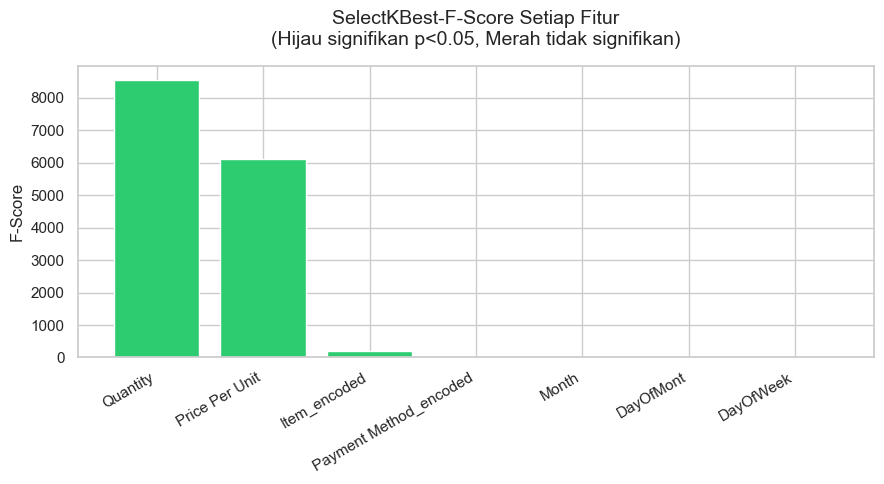

In [28]:
#Visualisasi F-Score
plt.figure(figsize=(9, 5))
bar_colors = ['#2ecc71' if p < 0.05 else '#e74c3c' for p in skb_results['P-Value']]

plt.bar(skb_results['Fitur'], skb_results['F-Score'], color=bar_colors)
plt.xticks(rotation=30, ha='right')
plt.title('SelectKBest-F-Score Setiap Fitur\n(Hijau signifikan p<0.05, Merah tidak signifikan)', fontsize=14, pad=15)
plt.ylabel('F-Score')
plt.tight_layout()
plt.show()

In [29]:
#Pilih K Fitur Terbaik

K = 4 #ubah nilai K sesuai kebutuhan

selector_k = SelectKBest(score_func=f_regression, k=K)
X_selected = selector_k.fit_transform(x, y)

#Nama fitur yang terpilih
selected_mask = selector_k.get_support()
selected_features = [col for col, sel in zip(x.columns, selected_mask) if sel]
dropped_features = [col for col, sel in zip(x.columns, selected_mask) if not sel]

print(f'SelectKBest dengan K ({K})')
print(f'\nFitur TERPILIH ({len(selected_features)}): {selected_features}')
print(f'Fitur TIDAK dipilih ({len(dropped_features)}): {dropped_features}')
print(f'\nShape X setelah SelectKBest: {X_selected.shape}')

SelectKBest dengan K (4)

Fitur TERPILIH (4): ['Quantity', 'Price Per Unit', 'Item_encoded', 'Payment Method_encoded']
Fitur TIDAK dipilih (3): ['Month', 'DayOfWeek', 'DayOfMont']

Shape X setelah SelectKBest: (8613, 4)


In [34]:
# Tabel Perbandingan
comparison = pd.DataFrame({
    'Fitur'           : x.columns,
    'Pearson |r|'     : [round(abs(corr_with_target.get(f, 0)), 4) for f in x.columns],
    'Pearson Dipilih' : ['dipilih' if f in selected_by_pearson else 'tidak dipilih' for f in x.columns],
    'SKB F-Score'     : [round(selector_all.scores_[i], 2) for i, f in enumerate(x.columns)],
    'SKB P-Value'     : [round(selector_all.pvalues_[i], 4) for i, f in enumerate(x.columns)],
    'SKB Top-{K}'     : ['dipilih' if f in selected_features else 'tidak dipilih' for f in x.columns],
}).sort_values('SKB F-Score', ascending=False)

print('Perbandingan Pearson Correlation vs SelectKBest:')
comparison

Perbandingan Pearson Correlation vs SelectKBest:


,Fitur,Pearson |r|,Pearson Dipilih,SKB F-Score,SKB P-Value,SKB Top-{K}
0,Quantity,0.7060,dipilih,8556.87,0.0000,dipilih
1,Price Per Unit,0.6445,dipilih,6117.59,0.0000,dipilih
5,Item_encoded,0.1516,dipilih,202.66,0.0000,dipilih
6,Payment Method_encoded,0.0194,tidak dipilih,3.23,0.0725,dipilih
2,Month,0.0059,tidak dipilih,0.30,0.5867,tidak dipilih
4,DayOfMont,0.0054,tidak dipilih,0.25,0.6179,tidak dipilih
3,DayOfWeek,0.0044,tidak dipilih,0.17,0.6825,tidak dipilih
